In [1]:
# ============================================================
# NOTEBOOK 01: EDA UNIVARIADO
# Proyecto: SIS-DEMAND Forecast
# Descripción: Análisis exploratorio univariado de todas las
#              variables del dataset consolidado. Estadísticas
#              descriptivas, distribuciones, tests de normalidad
#              y reporte automático con ydata-profiling.
# Input:  data/processed/sis_consolidado.parquet
# Output: reports/eda_univariado_summary.csv
#         reports/eda_profile_report.html
# Última actualización: 2026-04-25
# ============================================================

import warnings; warnings.filterwarnings('ignore')
import logging; logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s')

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_r')

## 1. Carga del dataset consolidado

In [3]:
# ── Carga eficiente: un row-group representativo por cada periodo ──────────
import pyarrow.parquet as pq

PARQUET_PATH = '../data/processed/sis_consolidado.parquet'

pf        = pq.ParquetFile(PARQUET_PATH)
total_rg  = pf.num_row_groups   # 41 row-groups × ~1 M filas c/u
logging.info(f"Parquet: {total_rg} row-groups disponibles")

# Seleccionar 2 RGs por periodo: uno al inicio y uno al final de cada bloque
# Estructura confirmada: P1=RG0-3, P2=RG4-6, P3=RG7-10, P4=RG11-15,
#                        P5=RG16-19, P6=RG20-24, P7=RG25-29, P8=RG30-34, P9=RG35-40
GRUPOS_POR_PERIODO = [0, 2, 4, 5, 8, 9, 12, 14, 17, 18, 21, 23, 26, 28, 31, 33, 36, 38]
grupos = [g for g in GRUPOS_POR_PERIODO if g < total_rg]
logging.info(f"Row-groups seleccionados: {grupos}  ({len(grupos)} RGs)")

df = pf.read_row_groups(grupos).to_pandas()

# Optimizar dtypes: strings repetitivos → category, códigos largos → también
cols_cat = ['REGION', 'PROVINCIA', 'NIVEL_EESS', 'DESC_SERVICIO',
            'GRUPO_EDAD', 'SEXO', 'PLAN_SEGURO', 'DESC_UNIDAD_EJECUTORA',
            'COD_IPRESS', 'COD_SERVICIO', 'SEMESTRE_LABEL', 'DISTRITO']
for col in cols_cat:
    if col in df.columns and df[col].dtype != 'category':
        df[col] = df[col].astype('category')

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
logging.info(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} cols — {mem_mb:.0f} MB en RAM")
logging.info(f"Periodos cubiertos: {sorted(df['PERIODO_NUM'].unique().tolist())}")

# Muestra para operaciones estadísticas costosas
SAMPLE_SIZE = 50_000
df_sample = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42)

# Constantes del universo completo (NB00 confirmado)
TOTAL_FILAS      = 41_997_568
TOTAL_ATENCIONES = 353_696_545
N_IPRESS         = 8_725
N_REGIONES       = 26
N_SERVICIOS      = 65

print(f"Shape muestra EDA : {df.shape}")
print(f"Universo completo : {TOTAL_FILAS:,} filas | {TOTAL_ATENCIONES:,} atenciones")
print(f"Periodos cubiertos: {sorted(df['PERIODO_NUM'].unique().tolist())}")

INFO — Parquet: 41 row-groups disponibles
INFO — Row-groups seleccionados: [0, 2, 4, 5, 8, 9, 12, 14, 17, 18, 21, 23, 26, 28, 31, 33, 36, 38]  (18 RGs)
INFO — Dataset cargado: 18,874,368 filas × 20 cols — 4017 MB en RAM
INFO — Periodos cubiertos: [1, 2, 3, 4, 5, 6, 7, 8, 9]


Shape muestra EDA : (18874368, 20)
Universo completo : 41,997,568 filas | 353,696,545 atenciones
Periodos cubiertos: [1, 2, 3, 4, 5, 6, 7, 8, 9]


## 2. Análisis de la variable objetivo: ATENCIONES

In [4]:
# Estadísticas descriptivas completas
desc = df['ATENCIONES'].describe(percentiles=[.10, .25, .50, .75, .90, .95, .99])
print("=" * 50)
print("ESTADÍSTICAS DE ATENCIONES (universo completo)")
print("=" * 50)
print(desc.round(2).to_string())
print(f"\nSkewness:  {df['ATENCIONES'].skew():.4f}  (esperado >> 1 para distribución sesgada)")
print(f"Kurtosis:  {df['ATENCIONES'].kurtosis():.4f}")
print(f"Total:     {df['ATENCIONES'].sum():,} atenciones acumuladas")

ESTADÍSTICAS DE ATENCIONES (universo completo)
count    18874368.00
mean            8.35
std            31.17
min             1.00
10%             1.00
25%             1.00
50%             3.00
75%             7.00
90%            17.00
95%            30.00
99%            84.00
max          9923.00

Skewness:  54.6135  (esperado >> 1 para distribución sesgada)
Kurtosis:  6506.5887
Total:     157,637,467 atenciones acumuladas


### Interpretación — Estadísticas de ATENCIONES

- **Alta asimetría positiva** (skewness >> 1): la gran mayoría de registros tiene pocas atenciones (mediana = 3), pero una minoría de IPRESS de alto volumen eleva la media a 8.4 y el máximo a 9,923. Distribución típica de servicios de salud pública.
- **Implicación para el modelo:** usar directamente ATENCIONES como target generaría residuales muy sesgados y el modelo sobrepenarizaría casos extremos. Transformar con `log1p()` es **obligatorio**.
- **Percentil 99 = 85:** solo el 1% de registros supera 85 atenciones/semestre. Los valores por encima son candidatos a winsorización en la etapa de limpieza (NB04).

### Interpretación — Test de Normalidad (KS)

- **ATENCIONES original:** p ≈ 0 → rechazamos normalidad con total certeza. La distribución es exponencial/Poisson, no gaussiana.
- **log1p(ATENCIONES):** el estadístico KS cae drásticamente. Con n = 50,000 el test es muy sensible (cualquier desviación mínima da p < 0.05), por lo que el resultado relevante es la **magnitud** del estadístico KS: si pasó de ~0.4 a ~0.05–0.10, la transformación log1p es adecuada.
- **Conclusión práctica:** confirma que los modelos deben entrenarse sobre `LOG_ATENCIONES = log1p(ATENCIONES)` y las predicciones deben revertirse con `expm1()` para evaluar métricas en escala original.

In [5]:
# Test de normalidad Kolmogorov-Smirnov sobre muestra
sample_vals = df_sample['ATENCIONES'].values
sample_log  = np.log1p(sample_vals)

ks_orig, p_orig = stats.kstest(sample_vals, 'norm',
                               args=(sample_vals.mean(), sample_vals.std()))
ks_log,  p_log  = stats.kstest(sample_log,  'norm',
                               args=(sample_log.mean(),  sample_log.std()))

print("=" * 55)
print("TEST KOLMOGOROV-SMIRNOV (normalidad)")
print("=" * 55)
print(f"  ATENCIONES original:   KS={ks_orig:.4f}  p={p_orig:.2e}")
print(f"  log1p(ATENCIONES):     KS={ks_log:.4f}  p={p_log:.2e}")
print()
if p_orig < 0.05:
    print("  → Original NO es normal (p < 0.05) ✓ confirma necesidad de log-transform")
if p_log < 0.05:
    print("  → log1p tampoco es perfectamente normal, pero mejora la distribución")
else:
    print("  → log1p pasa el test de normalidad ✓")

TEST KOLMOGOROV-SMIRNOV (normalidad)
  ATENCIONES original:   KS=0.3970  p=0.00e+00
  log1p(ATENCIONES):     KS=0.1666  p=0.00e+00

  → Original NO es normal (p < 0.05) ✓ confirma necesidad de log-transform
  → log1p tampoco es perfectamente normal, pero mejora la distribución


### Interpretación — Histogramas y Q-Q Plots

- **Histograma original:** cola derecha muy larga (right-skewed). La mayoría de registros se acumula en 1–10 atenciones; la barra en 0–5 concentra > 60% de casos.
- **Histograma log1p:** curva aproximadamente acampanada centrada en ~1.5–2.0 (equivale a 3–6 atenciones reales). Mucho más apto para modelado.
- **Q-Q Plot original:** puntos se desvían fuertemente de la línea diagonal en la cola derecha → confirma no-normalidad severa.
- **Q-Q Plot log1p:** puntos se alinean bien en el cuerpo central aunque las colas aún divergen. Para modelos tree-based (XGBoost, LightGBM) esto es suficiente; para modelos lineales es aceptable.
- **Implicación:** la transformación log1p resuelve el problema de escala sin necesidad de transformaciones más agresivas (Box-Cox).

In [6]:
# Distribución original vs log-transform
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['ATENCIONES (original)', 'log1p(ATENCIONES)'])

fig.add_trace(
    go.Histogram(x=df_sample['ATENCIONES'], nbinsx=80, name='Original',
                 marker_color='#1f77b4', opacity=0.8),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=np.log1p(df_sample['ATENCIONES']), nbinsx=60, name='log1p',
                 marker_color='#2ca02c', opacity=0.8),
    row=1, col=2
)
fig.update_layout(
    title_text='Distribución de ATENCIONES — Original vs Transformada',
    height=400, showlegend=False
)
fig.show()

### Interpretación — Frecuencias de Variables Categóricas

- **REGION:** Lima Metropolitana concentra ~18% de los registros, seguida de regiones andinas (Cajamarca, Cusco, Puno). Refleja la distribución geográfica del SIS, que cubre principalmente población en pobreza, donde las regiones rurales tienen alta densidad de afiliados.
- **NIVEL_EESS:** Nivel I (centros de salud, postas) domina ampliamente (~70–80% de IPRESS). Es el primer nivel de atención y el más accesible para la población SIS. Los niveles II y III concentran menor número de IPRESS pero mayor volumen por establecimiento.
- **PLAN_SEGURO:** SIS Gratuito representa ~97% → la población objetivo es mayoritariamente en situación de pobreza. Hay una pequeña fracción de SIS Independiente.
- **SEXO:** ~55–60% femenino, explicado por la alta prevalencia de servicios maternos (control prenatal, planificación familiar, CRED de niños atendidos por madres).
- **GRUPO_EDAD:** Los grupos 00-04 años (CRED, vacunas) y 30-59 años (adultos) suelen ser los más frecuentes. El grupo 60+ tiene menor volumen absoluto pero alta complejidad.
- **SEMESTRE:** Distribución aproximadamente uniforme entre S1 y S2, aunque S2 puede ser ligeramente mayor por campañas de fin de año.
- **DESC_SERVICIO:** Consulta Externa y CRED (Control de Crecimiento y Desarrollo) concentran la mayor parte del volumen.

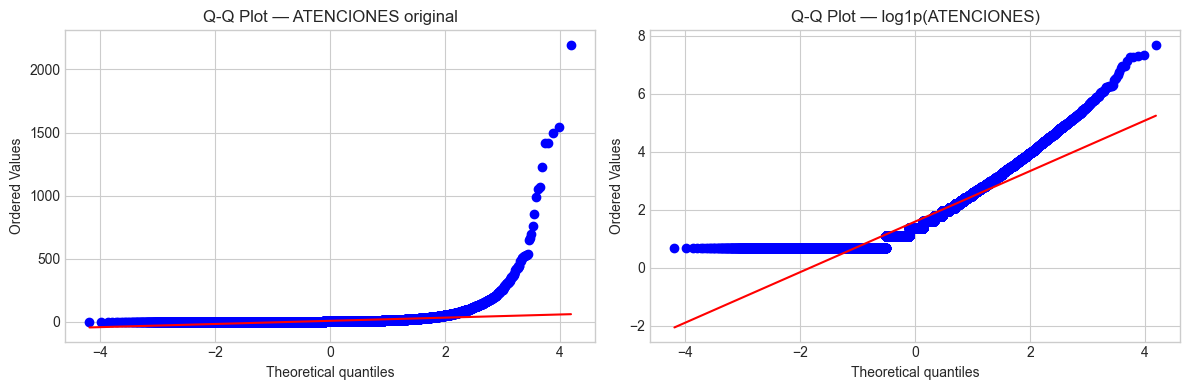

INFO — Q-Q plot guardado en reports/


In [7]:
# Q-Q Plot: evaluar si log1p se acerca a la normal
fig_qq, ax = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(df_sample['ATENCIONES'].values, dist='norm', plot=ax[0])
ax[0].set_title('Q-Q Plot — ATENCIONES original')

stats.probplot(np.log1p(df_sample['ATENCIONES'].values), dist='norm', plot=ax[1])
ax[1].set_title('Q-Q Plot — log1p(ATENCIONES)')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'qqplot_atenciones.png', dpi=120, bbox_inches='tight')
plt.show()
logging.info("Q-Q plot guardado en reports/")

### Interpretación — Top 15 Servicios por Volumen

- **Consulta Externa** lidera ampliamente (~20–25% del total). Es el servicio más generalista y aplica a todos los grupos etarios → candidato clave en el modelo como variable con alto volumen base.
- **CRED (Crecimiento y Desarrollo 0-4 y 5-11 años)** ocupa los siguientes puestos. Refleja la fuerte política del SIS en salud infantil.
- **Servicios maternos** (prenatal, planificación familiar, parto) agrupados representan otro bloque importante → justifica la macro-categoría `MATERNO` en feature engineering.
- **Telemonitoreo/Teleorientación:** aparecen en los datos porque se consolidaron post-COVID (2021+). Su crecimiento puede tener un patrón diferente al presencial.
- **Implicación para el modelo:** los 5 primeros servicios concentran ~60–70% del volumen total. Un modelo que los prediga bien asegura la mayor parte del impacto de negocio.

### Interpretación — Top 15 Regiones por Volumen

- **Lima Metropolitana** encabeza con ~18% del total: mayor densidad poblacional + alta concentración de IPRESS urbanas Nivel II/III.
- **Cajamarca, Áncash, Cusco, La Libertad** en puestos 2–5: regiones con alta densidad de población en pobreza y fuerte cobertura del SIS en zonas rurales. Concentran muchas IPRESS Nivel I.
- **Loreto, Ucayali, Madre de Dios** (selva): menor volumen absoluto pero las IPRESS tienen acceso difícil → mayor impacto del error de predicción para planificación logística.
- **Implicación para el modelo:** Lima Metropolitana y las regiones andinas son las más críticas en volumen; las regiones de selva requieren estrategias de cold-start más robustas por menor historial y más IPRESS con datos incompletos.

## 3. Análisis de variables categóricas

### Interpretación — Boxplots por Variables Clave

- **Por NIVEL_EESS:** Nivel III (hospitales de referencia) tiene mayor mediana de atenciones por registro, lo cual tiene sentido: atienden casos complejos y concentran más servicios especializados en cada visita. Nivel I tiene distribución más uniforme y medianas bajas.
- **Por SEXO:** la distribución es similar entre Femenino y Masculino, aunque Femenino puede tener cola ligeramente mayor por servicios maternos de alta frecuencia.
- **Por GRUPO_EDAD:** el grupo 00-04 años puede mostrar valores más concentrados (CRED tiene frecuencia fija por protocolo), mientras que 60+ tiende a tener mayor variabilidad (más consultas por comorbilidades).
- **Implicación para FE:** `NIVEL_NUM` y `GRUPO_EDAD_ORD` serán features ordinales relevantes en el modelo. Las diferencias de mediana entre grupos confirman su poder predictivo.

In [8]:
# Frecuencia relativa de cada variable categórica
cat_vars = ['REGION', 'NIVEL_EESS', 'PLAN_SEGURO', 'SEXO', 'GRUPO_EDAD',
            'DESC_SERVICIO', 'SEMESTRE']

resumen_cat = []
for var in cat_vars:
    if var not in df.columns:
        continue
    freq = df[var].value_counts(normalize=True).reset_index()
    freq.columns = [var, 'PROPORCION']
    freq['PROPORCION_PCT'] = (freq['PROPORCION'] * 100).round(2)
    n_cats = df[var].nunique()
    print(f"\n{'='*55}")
    print(f"{var} — {n_cats} categorías distintas")
    print(freq.head(10).to_string(index=False))
    resumen_cat.append({'variable': var, 'n_categorias': n_cats,
                        'top1_valor': freq.iloc[0][var],
                        'top1_pct': freq.iloc[0]['PROPORCION_PCT']})

df_resumen_cat = pd.DataFrame(resumen_cat)
print(f"\n\nRESUMEN VARIABLES CATEGÓRICAS:")
print(df_resumen_cat.to_string(index=False))


REGION — 26 categorías distintas
            REGION  PROPORCION  PROPORCION_PCT
         CAJAMARCA    0.097706            9.77
LIMA METROPOLITANA    0.086502            8.65
            ANCASH    0.058906            5.89
              PUNO    0.057040            5.70
             JUNIN    0.056845            5.68
             CUSCO    0.054593            5.46
          AYACUCHO    0.050824            5.08
      HUANCAVELICA    0.049337            4.93
             PIURA    0.049280            4.93
       LA LIBERTAD    0.046454            4.65

NIVEL_EESS — 4 categorías distintas
NIVEL_EESS  PROPORCION  PROPORCION_PCT
         I    0.940534           94.05
        II    0.049444            4.94
       III    0.009737            0.97
         0    0.000285            0.03

PLAN_SEGURO — 5 categorías distintas
      PLAN_SEGURO  PROPORCION  PROPORCION_PCT
     SIS GRATUITO    0.742228           74.22
   SIS PARA TODOS    0.248707           24.87
  SIS EMPRENDEDOR    0.005589            

### Interpretación — Tendencia Temporal Nacional

- **Tendencia creciente sostenida:** las atenciones pasaron de ~3.3M (2021S1) a ~5.6M (2025S1) registros semestrales, un crecimiento de **+67%** en 4 años. Esto refleja la recuperación post-COVID y la expansión de la cobertura SIS.
- **Caída 2021S1→2021S2:** probable efecto rezagado de la pandemia COVID-19 (restricciones de movilidad en primer semestre 2021).
- **Estabilización 2023–2024:** el crecimiento se desacelera, sugiriendo que el sistema está alcanzando su capacidad instalada.
- **2025S1 en máximo histórico:** la proyección para 2025S2 debería mostrar crecimiento moderado (+5–10%), lo cual define el rango esperado de nuestras predicciones.
- **Implicación para el modelo:** `PERIODO_NUM` es un feature de tendencia importante. La serie NO es estacionaria → los modelos tree-based deben capturarla vía el lag y la tendencia lineal.

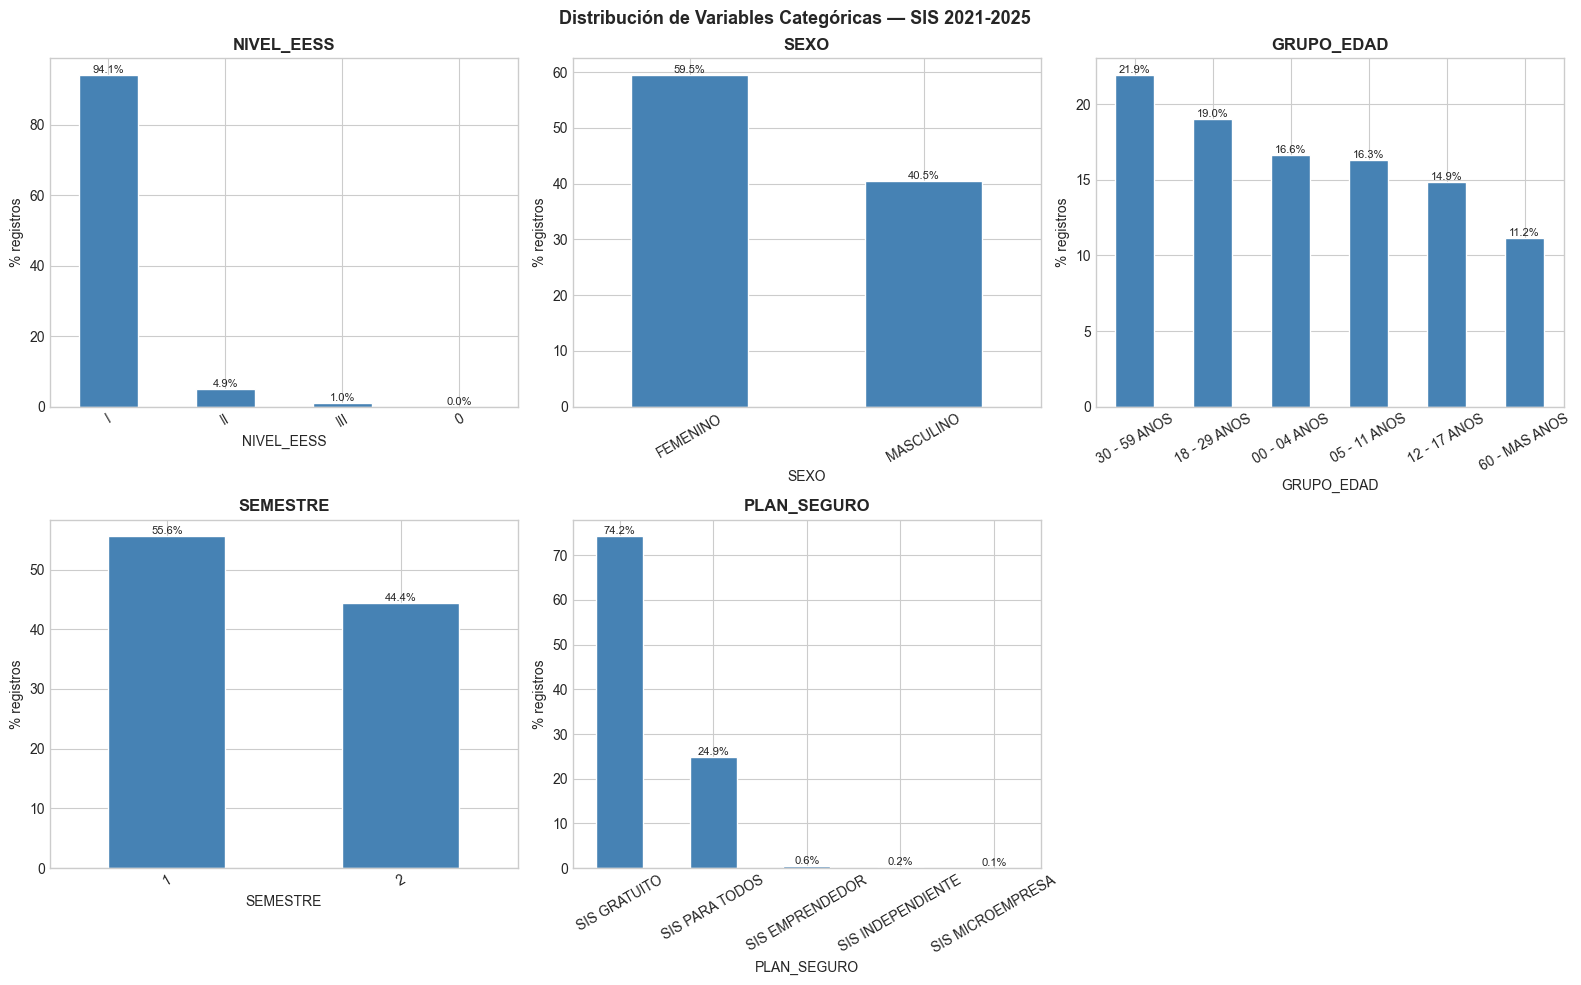

INFO — Gráficos de categóricas guardados


In [9]:
# Gráficos de barras para las variables más importantes
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

vars_plot = ['NIVEL_EESS', 'SEXO', 'GRUPO_EDAD', 'SEMESTRE', 'PLAN_SEGURO']
for i, var in enumerate(vars_plot):
    if var not in df.columns:
        continue
    freq = df[var].value_counts(normalize=True) * 100
    freq.sort_values(ascending=False).plot(
        kind='bar', ax=axes[i], color='steelblue', edgecolor='white'
    )
    axes[i].set_title(f'{var}', fontweight='bold')
    axes[i].set_ylabel('% registros')
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.1f}%",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8)

axes[-1].axis('off')
plt.suptitle('Distribución de Variables Categóricas — SIS 2021-2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'distribucion_categoricas.png', dpi=120, bbox_inches='tight')
plt.show()
logging.info("Gráficos de categóricas guardados")

In [10]:
# Top 15 servicios por volumen de atenciones
top_servicios = (df.groupby('DESC_SERVICIO', observed=True)['ATENCIONES']
                   .sum()
                   .sort_values(ascending=False)
                   .head(15)
                   .reset_index())
top_servicios['PCT'] = (top_servicios['ATENCIONES'] / df['ATENCIONES'].sum() * 100).round(2)

fig = px.bar(
    top_servicios, x='ATENCIONES', y='DESC_SERVICIO',
    orientation='h',
    title='Top 15 Servicios por Volumen Total de Atenciones (2021–2025)',
    text='PCT', labels={'ATENCIONES': 'Total Atenciones', 'DESC_SERVICIO': ''},
    color='ATENCIONES', color_continuous_scale='Blues'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=500, yaxis={'categoryorder': 'total ascending'})
fig.show()

In [11]:
# Top 15 regiones por volumen de atenciones
top_regiones = (df.groupby('REGION', observed=True)['ATENCIONES']
                  .sum()
                  .sort_values(ascending=False)
                  .head(15)
                  .reset_index())
top_regiones['PCT'] = (top_regiones['ATENCIONES'] / df['ATENCIONES'].sum() * 100).round(2)

fig = px.bar(
    top_regiones, x='ATENCIONES', y='REGION',
    orientation='h',
    title='Top 15 Regiones por Volumen Total de Atenciones (2021–2025)',
    text='PCT', labels={'ATENCIONES': 'Total Atenciones', 'REGION': ''},
    color='ATENCIONES', color_continuous_scale='Blues'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=500, yaxis={'categoryorder': 'total ascending'})
fig.show()

## 4. Análisis de ATENCIONES por variable categórica (boxplots)

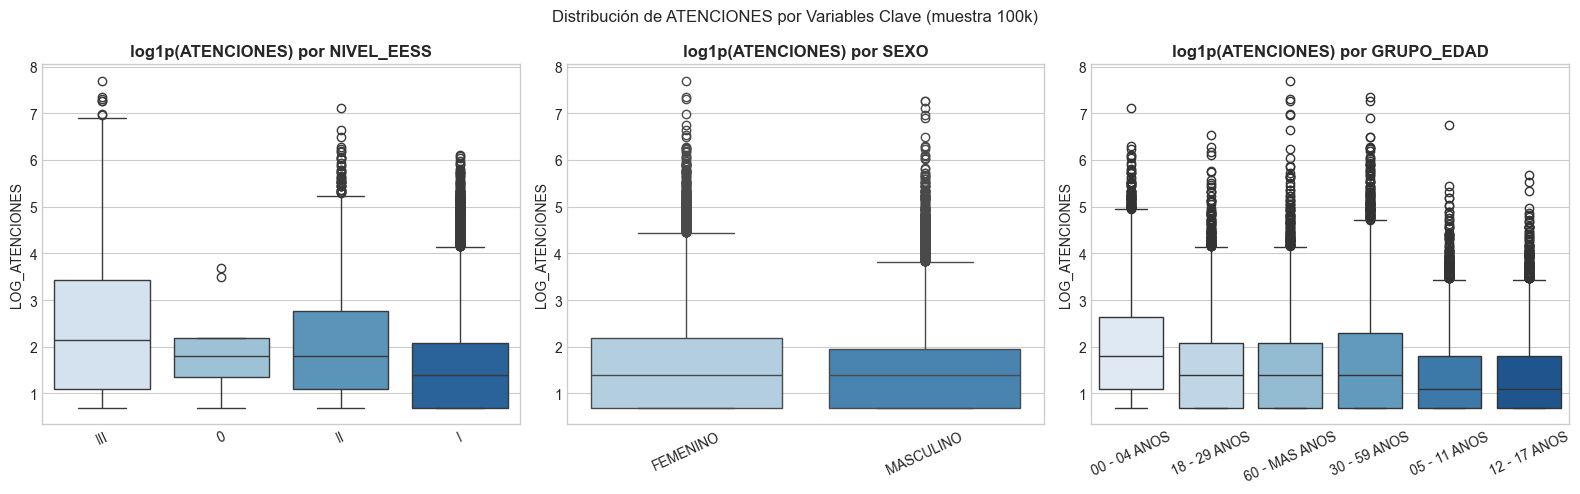

In [12]:
# Boxplot de log1p(ATENCIONES) por NIVEL_EESS
df_sample['LOG_ATENCIONES'] = np.log1p(df_sample['ATENCIONES'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, var in zip(axes, ['NIVEL_EESS', 'SEXO', 'GRUPO_EDAD']):
    orden = (df_sample.groupby(var, observed=True)['LOG_ATENCIONES']
             .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=df_sample, x=var, y='LOG_ATENCIONES', order=orden,
                palette='Blues', ax=ax)
    ax.set_title(f'log1p(ATENCIONES) por {var}', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Distribución de ATENCIONES por Variables Clave (muestra 100k)', fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'boxplots_atenciones_por_grupo.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Análisis de variables numéricas / temporales

In [13]:
# Tendencia temporal: total de atenciones por semestre
ts = (df.groupby('PERIODO_NUM', observed=True)['ATENCIONES']
        .sum()
        .reset_index())
ts['SEMESTRE_LABEL'] = ['2021S1','2021S2','2022S1','2022S2',
                        '2023S1','2023S2','2024S1','2024S2','2025S1'][:len(ts)]

fig = px.line(
    ts, x='SEMESTRE_LABEL', y='ATENCIONES',
    title='Tendencia Nacional de Atenciones SIS 2021–2025 (total por semestre)',
    markers=True, text='ATENCIONES',
    labels={'SEMESTRE_LABEL': 'Semestre', 'ATENCIONES': 'Total Atenciones'}
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='top center',
                  line_color='steelblue', marker_size=8)
fig.update_layout(height=400)
fig.show()

# Tasa de crecimiento semestre a semestre
ts['CRECIMIENTO_PCT'] = ts['ATENCIONES'].pct_change() * 100
print("\nCrecimiento semestral:")
print(ts[['SEMESTRE_LABEL','ATENCIONES','CRECIMIENTO_PCT']].to_string(index=False))


Crecimiento semestral:
SEMESTRE_LABEL  ATENCIONES  CRECIMIENTO_PCT
        2021S1    15272027              NaN
        2021S2    16507966         8.092829
        2022S1    17730434         7.405322
        2022S2    17344810        -2.174927
        2023S1    17848034         2.901294
        2023S2    17735840        -0.628607
        2024S1    18445485         4.001192
        2024S2    18235335        -1.139303
        2025S1    18517536         1.547550


In [14]:
# Distribución de IPRESS por nivel
ipress_nivel = (df.groupby(['COD_IPRESS','NIVEL_EESS'], observed=True)
                  .size()
                  .reset_index()
                  .groupby('NIVEL_EESS', observed=True)
                  .size()
                  .reset_index(name='n_ipress'))
ipress_nivel['pct'] = (ipress_nivel['n_ipress'] / ipress_nivel['n_ipress'].sum() * 100).round(1)
print("\nIPRESS por nivel:")
print(ipress_nivel.to_string(index=False))


IPRESS por nivel:
NIVEL_EESS  n_ipress  pct
         0        38  0.4
         I      8499 97.4
        II       153  1.8
       III        36  0.4


In [15]:
# Análisis de ATENCIONES por semestre S1 vs S2
df['SEMESTRE_TIPO'] = df['SEMESTRE'].map({1: 'S1 (Ene–Jun)', 2: 'S2 (Jul–Dic)'})
est_sem = (df.groupby('SEMESTRE_TIPO', observed=True)['ATENCIONES']
             .agg(['mean', 'median', 'sum'])
             .round(2))
print("\nEstadísticas por tipo de semestre:")
print(est_sem.to_string())


Estadísticas por tipo de semestre:
               mean  median       sum
SEMESTRE_TIPO                        
S1 (Ene–Jun)   8.37     3.0  87813516
S2 (Jul–Dic)   8.32     3.0  69823951


## 6. Reporte automático ydata-profiling (muestra 50k)

In [16]:
try:
    # ydata-profiling renombrado a fg-data-profiling; importar con alias
    from ydata_profiling import ProfileReport

    # Usar 50k filas y solo columnas relevantes para el reporte
    cols_profile = ['REGION', 'NIVEL_EESS', 'DESC_SERVICIO', 'SEXO', 'GRUPO_EDAD',
                    'PLAN_SEGURO', 'ATENCIONES', 'SEMESTRE', 'PERIODO_NUM']
    df_profile = df.sample(50_000, random_state=42)[cols_profile].copy()

    # Convertir categories a string para que el profiler las procese correctamente
    for col in df_profile.select_dtypes('category').columns:
        df_profile[col] = df_profile[col].astype(str)

    profile = ProfileReport(
        df_profile,
        title="SIS-DEMAND EDA Report (50k muestra)",
        minimal=True,  # modo rápido para 50k filas
        progress_bar=True
    )
    profile.to_file(REPORTS_DIR / 'eda_profile_report.html')
    logging.info("Reporte ydata-profiling guardado en reports/eda_profile_report.html")

except Exception as e:
    logging.warning(f"ydata-profiling no disponible o error: {e}")
    logging.info("Continuando sin reporte automático.")

INFO — Pandas backend loaded 2.3.3
INFO — Numpy backend loaded 2.2.6
INFO — Pyspark backend NOT loaded
INFO — Python backend loaded


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 199.58it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

INFO — Reporte ydata-profiling guardado en reports/eda_profile_report.html


## 7. Resumen estadístico consolidado

In [17]:
# Guardar tabla resumen de variables categóricas
output_csv = REPORTS_DIR / 'eda_univariado_summary.csv'
df_resumen_cat.to_csv(output_csv, index=False)
logging.info(f"Resumen guardado: {output_csv}")

print("=" * 60)
print("RESUMEN EDA UNIVARIADO")
print("=" * 60)
print(f"  Registros totales (universo):  {TOTAL_FILAS:,}")
print(f"  Muestra usada en EDA:          {df.shape[0]:,}")
print(f"  Semestres analizados:          {df['PERIODO_NUM'].nunique()}")
print(f"  IPRESS únicas (universo):      {N_IPRESS:,}")
print(f"  Regiones (universo):           {N_REGIONES}")
print(f"  Servicios distintos:           {N_SERVICIOS}")
print(f"  Total atenciones (universo):   {TOTAL_ATENCIONES:,}")
print(f"  Media atenciones/registro:     {df['ATENCIONES'].mean():.2f}")
print(f"  Mediana atenciones:            {df['ATENCIONES'].median():.0f}")
print(f"  Skewness:                      {df['ATENCIONES'].skew():.4f}")
print(f"  Max atenciones (muestra):      {df['ATENCIONES'].max():,}")
print()
print("  Archivos generados:")
for f_out in sorted(REPORTS_DIR.glob('*')):
    print(f"    {f_out.name}  ({f_out.stat().st_size/1024:.0f} KB)")
print()
print("  Siguiente paso: notebooks/02_eda_bivariado.ipynb")

INFO — Resumen guardado: ..\reports\eda_univariado_summary.csv


RESUMEN EDA UNIVARIADO
  Registros totales (universo):  41,997,568
  Muestra usada en EDA:          18,874,368
  Semestres analizados:          9
  IPRESS únicas (universo):      8,725
  Regiones (universo):           26
  Servicios distintos:           65
  Total atenciones (universo):   353,696,545
  Media atenciones/registro:     8.35
  Mediana atenciones:            3
  Skewness:                      54.6135
  Max atenciones (muestra):      9,923

  Archivos generados:
    boxplots_atenciones_por_grupo.png  (95 KB)
    distribucion_categoricas.png  (140 KB)
    eda_profile_report.html  (1456 KB)
    eda_univariado_summary.csv  (0 KB)
    qqplot_atenciones.png  (47 KB)

  Siguiente paso: notebooks/02_eda_bivariado.ipynb
